# IBM AML 패턴 외 자금세탁 이력 피처 그룹 기여도 실험 v5

이 노트북은 기존 small_eda2.ipynb에 이어 붙이지 않고 독립적으로 실행할 수 있도록 작성했습니다.

목표는 불필요·중복 피처를 정리한 동일한 기준 모델에서 계좌 이력 피처 그룹을 하나씩 추가해 각 그룹의 성능 기여도를 분리하는 것입니다. 이 단계에서는 is_new_pair와 시간대 제거 실험을 섞지 않습니다.


## 실험 정의

- 양성 1: Is Laundering이 1이면서 Patterns.txt에 없는 거래
- 음성 0: Is Laundering이 0인 정상거래
- 사전 제거: Patterns.txt에 있으면서 Is Laundering이 1인 패턴 자금세탁 거래
- 분석 기간: 2022-09-01부터 2022-09-10까지
- Reinvestment: 시뮬레이션 초기 잔액 성격이므로 기본적으로 제외
- Patterns.txt에 Is Laundering이 0인 거래가 있더라도 역할을 단정할 수 없으므로 제거하지 않고 원본 정상 라벨을 유지
- HI-Small의 Patterns.txt에는 Is Laundering이 0인 거래가 없는지 코드로 별도 확인
- 패턴 자금세탁은 과거 계좌 행동 피처를 계산하기 전에 제거하므로 거래 횟수와 과거 평균에도 포함되지 않음
- 금액: 데이터에서 확인한 고정환율로 모든 통화를 USD로 환산
- 모델에서 제거: log_amount_received_usd, Payment Currency, Receiving Currency, is_cross_currency
- 공통 기준 피처: log_amount_paid_usd, log_amount_ratio_usd, is_cross_bank, is_self_transfer, hour_sin, hour_cos
- H0: 이력 피처 없음
- H1: pair_prev_count_log
- H2: sender_prev_count_log, receiver_prev_count_log
- H3: hours_since_sender_prev_log, amount_vs_sender_history_usd
- H4: 이력 피처 5개 전체
- 계속 제외: Payment Format, 원본 Timestamp, 날짜, 요일, 주말 여부
- 시간 분할: 학습 1~7일, 검증 8일, 테스트 9~10일

모든 H 실험은 같은 학습·검증·테스트 표본, 언더샘플링, class_weight, random_state, 모델 설정과 Threshold 선택 방식을 사용합니다. 성능 차이는 추가된 이력 피처 그룹의 기여도로 해석합니다.


In [1]:
# 추가 패키지 설치 없이 scikit-learn만 사용합니다.

In [2]:
import csv
import gc
import shutil
import warnings
from io import StringIO
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 100)
sns.set_theme(style='whitegrid')


## 1. 데이터 경로와 실행 옵션

small_eda2.ipynb와 동일하게 현재 작업 폴더 아래 datasets 폴더를 사용합니다. MODEL_RATIO를 HI 또는 LI로 바꾸면 해당 데이터셋을 학습합니다. H0~H4가 같은 이력값을 공유하도록 과거 행동 피처는 한 번만 계산합니다.


In [3]:
MODEL_RATIO = 'HI'  # LI를 분석하려면 'LI'로 변경
RATIOS = [MODEL_RATIO]  # 메모리를 아끼기 위해 한 번에 한 데이터셋만 로드
SIZE = 'Small'

EXCLUDE_REINVESTMENT = True
USE_CAUSAL_HISTORY_FEATURES = True  # H0~H4 비교를 위해 이력 피처를 한 번 계산
NEGATIVE_SAMPLE_RATIO = 10  # 학습 양성 1건당 정상거래 10건

PRIMARY_END = pd.Timestamp('2022-09-11 00:00')
TRAIN_END = pd.Timestamp('2022-09-08 00:00')
VALID_END = pd.Timestamp('2022-09-09 00:00')

DATASET_HANDLE = (
    'ealtman2019/'
    'ibm-transactions-for-anti-money-laundering-aml'
)

DATA_DIR = Path.cwd() / 'datasets'
DATA_DIR.mkdir(parents=True, exist_ok=True)

print('현재 작업 폴더:', Path.cwd())
print('데이터 저장 폴더:', DATA_DIR)
print('모델링 대상:', f'{MODEL_RATIO}-{SIZE}')


현재 작업 폴더: /workspace/money_laundry
데이터 저장 폴더: /workspace/money_laundry/datasets
모델링 대상: HI-Small


## 2. 필요한 파일 다운로드

이번 기준 실험에는 거래 파일과 패턴 파일만 사용합니다. accounts.csv의 엔티티 피처는 기준 모델을 확인한 뒤 추가하는 편이 좋습니다.


In [4]:
import kagglehub

wanted_files = []
for ratio in RATIOS:
    wanted_files.extend([
        f'{ratio}-{SIZE}_Trans.csv',
        f'{ratio}-{SIZE}_Patterns.txt',
    ])

for filename in wanted_files:
    destination = DATA_DIR / filename

    if destination.exists():
        print('이미 존재하므로 건너뜀:', destination.name)
        continue

    print('다운로드 시작:', filename)
    downloaded_path = Path(
        kagglehub.dataset_download(
            DATASET_HANDLE,
            path=filename,
        )
    )
    shutil.copy2(downloaded_path, destination)
    print('다운로드 완료:', destination)


이미 존재하므로 건너뜀: HI-Small_Trans.csv
이미 존재하므로 건너뜀: HI-Small_Patterns.txt


In [5]:
dataset_paths = {}

for ratio in RATIOS:
    dataset_paths[ratio] = {
        'transactions': DATA_DIR / f'{ratio}-{SIZE}_Trans.csv',
        'patterns': DATA_DIR / f'{ratio}-{SIZE}_Patterns.txt',
    }

for ratio, paths in dataset_paths.items():
    print(f'\n===== {ratio}-{SIZE} =====')
    for file_type, path in paths.items():
        if not path.exists():
            raise FileNotFoundError(f'파일이 없습니다: {path}')
        print(f'{file_type:<15}: {path.name}')



===== HI-Small =====
transactions   : HI-Small_Trans.csv
patterns       : HI-Small_Patterns.txt


## 3. Patterns.txt 파싱 함수

Patterns.txt의 BEGIN과 END 사이 거래를 읽고 Attempt ID와 Pattern Type을 붙입니다. 이 정보는 패턴 소속 거래를 학습 데이터에서 제외하는 데 사용합니다.


In [6]:
TRANSACTION_COLUMNS = [
    'Timestamp',
    'From Bank',
    'Account',
    'To Bank',
    'Account.1',
    'Amount Received',
    'Receiving Currency',
    'Amount Paid',
    'Payment Currency',
    'Payment Format',
    'Is Laundering',
]

ID_COLUMNS = ['From Bank', 'Account', 'To Bank', 'Account.1']
AMOUNT_COLUMNS = ['Amount Received', 'Amount Paid']
TEXT_COLUMNS = [
    'Receiving Currency',
    'Payment Currency',
    'Payment Format',
]

def parse_pattern_file(path, ratio):
    # 거래 한 행당 하나의 레코드로 변환합니다.
    records = []
    current = None
    attempt_number = 0
    transaction_order = 0

    with open(path, mode='r', encoding='utf-8', errors='replace') as file:
        for line_number, raw_line in enumerate(file, start=1):
            line = raw_line.strip()
            if not line:
                continue

            begin_prefix = 'BEGIN LAUNDERING ATTEMPT - '
            end_prefix = 'END LAUNDERING ATTEMPT - '

            if line.startswith(begin_prefix):
                if current is not None:
                    raise ValueError(f'{line_number}행: attempt 중첩')

                attempt_number += 1
                pattern_text = line[len(begin_prefix):].strip()
                parts = pattern_text.split(':', maxsplit=1)
                current = {
                    'Dataset': ratio,
                    'Attempt ID': f'{ratio}_{attempt_number:04d}',
                    'Attempt Number': attempt_number,
                    'Pattern Type': parts[0].strip().upper(),
                    'Pattern Meta': parts[1].strip() if len(parts) == 2 else '',
                }
                transaction_order = 0
                continue

            if line.startswith(end_prefix):
                if current is None:
                    raise ValueError(f'{line_number}행: BEGIN 없는 END')

                end_type = line[len(end_prefix):].strip().upper()
                if end_type != current['Pattern Type']:
                    raise ValueError(
                        f'{line_number}행: BEGIN/END 패턴 불일치'
                    )
                current = None
                transaction_order = 0
                continue

            if current is None:
                raise ValueError(f'{line_number}행: attempt 밖의 거래')

            values = next(csv.reader(StringIO(line)))
            if len(values) != len(TRANSACTION_COLUMNS):
                raise ValueError(
                    f'{line_number}행의 컬럼 수가 {len(values)}개입니다.'
                )

            transaction_order += 1
            records.append({
                **current,
                'Transaction Order': transaction_order,
                **dict(zip(TRANSACTION_COLUMNS, values)),
            })

    if current is not None:
        raise ValueError('마지막 attempt에 END가 없습니다.')

    return pd.DataFrame(records)


## 4. 거래와 패턴 데이터 로드 및 타입 통일

패턴 거래를 정확히 찾으려면 Timestamp, 계좌 ID, 금액, 라벨의 타입이 Trans.csv와 Patterns.txt에서 같아야 합니다. 이 단계가 다르면 모든 거래가 패턴 외로 잘못 분류될 수 있습니다.


In [7]:
transaction_dtypes = {column: 'string' for column in ID_COLUMNS}

def normalize_transaction_types(df):
    # 두 파일에 동일한 변환 규칙을 적용합니다.
    df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='raise')

    for column in ID_COLUMNS:
        df[column] = df[column].astype('string')

    for column in AMOUNT_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors='raise')

    for column in TEXT_COLUMNS:
        df[column] = df[column].astype('string')

    df['Is Laundering'] = (
        pd.to_numeric(df['Is Laundering'], errors='raise')
        .astype('int8')
    )
    return df

transactions = {}
pattern_transactions = {}

for ratio in RATIOS:
    print(f'\n{ratio}-{SIZE} 거래 로드 중...')
    trans = pd.read_csv(
        dataset_paths[ratio]['transactions'],
        dtype=transaction_dtypes,
        low_memory=False,
    )
    trans = normalize_transaction_types(trans)

    before = len(trans)
    trans = trans.drop_duplicates().reset_index(drop=True)
    print(f'완전 중복 제거: {before - len(trans):,}건')

    patterns = parse_pattern_file(
        dataset_paths[ratio]['patterns'],
        ratio,
    )
    patterns = normalize_transaction_types(patterns)

    transactions[ratio] = trans
    pattern_transactions[ratio] = patterns

    print('거래 행 수:', f'{len(trans):,}')
    print('패턴 거래 행 수:', f'{len(patterns):,}')
    print('패턴 Attempt 수:', patterns['Attempt ID'].nunique())



HI-Small 거래 로드 중...
완전 중복 제거: 9건
거래 행 수: 5,078,336
패턴 거래 행 수: 3,209
패턴 Attempt 수: 370


## 5. 패턴 소속 여부와 모델 클래스 생성

거래의 11개 원본 컬럼을 해시해 Trans.csv와 Patterns.txt를 비교합니다. 타입을 먼저 통일했기 때문에 날짜 문자열 형식이나 ID 타입 차이로 인한 오분류를 줄일 수 있습니다. Patterns.txt 안의 0 라벨 거래는 역할을 추정하지 않고 별도 건수만 확인합니다.


In [8]:
EXPECTED_COUNTS = {
    'HI': {'laundering': 5177, 'pattern': 3209, 'outside': 1968},
    'LI': {'laundering': 3565, 'pattern': 1023, 'outside': 2542},
}

classification_summary = {}

for ratio in RATIOS:
    trans = transactions[ratio]
    patterns = pattern_transactions[ratio]

    pattern_hashes = set(
        pd.util.hash_pandas_object(
            patterns[TRANSACTION_COLUMNS],
            index=False,
        ).astype('uint64')
    )

    trans_hashes = pd.util.hash_pandas_object(
        trans[TRANSACTION_COLUMNS],
        index=False,
    ).astype('uint64')

    trans['is_pattern_transaction'] = trans_hashes.isin(pattern_hashes)

    is_laundering = trans['Is Laundering'].eq(1)
    is_pattern_laundering = trans['is_pattern_transaction'] & is_laundering
    is_pattern_label0 = trans['is_pattern_transaction'] & (~is_laundering)
    is_outside = (~trans['is_pattern_transaction']) & is_laundering
    is_outside_normal = (~trans['is_pattern_transaction']) & (~is_laundering)

    trans['class_name'] = np.select(
        [is_pattern_laundering, is_outside],
        ['pattern_laundering', 'outside_laundering'],
        default='normal',
    )

    summary = {
        '전체 거래': len(trans),
        '전체 자금세탁': int(is_laundering.sum()),
        '패턴 파일 전체 거래': int(trans['is_pattern_transaction'].sum()),
        '패턴 자금세탁': int(is_pattern_laundering.sum()),
        '패턴 내 0 라벨 거래': int(is_pattern_label0.sum()),
        '패턴 외 자금세탁': int(is_outside.sum()),
        '전체 정상거래': int((~is_laundering).sum()),
        '패턴 밖 정상거래': int(is_outside_normal.sum()),
    }
    classification_summary[ratio] = summary

    expected = EXPECTED_COUNTS[ratio]
    observed = (
        summary['전체 자금세탁'],
        summary['패턴 자금세탁'],
        summary['패턴 외 자금세탁'],
    )
    expected_tuple = (
        expected['laundering'],
        expected['pattern'],
        expected['outside'],
    )
    if observed != expected_tuple:
        warnings.warn(
            f'{ratio} 집계가 기존 확인값과 다릅니다: '
            f'{observed} != {expected_tuple}'
        )

display(pd.DataFrame(classification_summary).T)


,전체 거래,전체 자금세탁,패턴 파일 전체 거래,패턴 자금세탁,패턴 내 0 라벨 거래,패턴 외 자금세탁,전체 정상거래,패턴 밖 정상거래
HI,5078336,5177,3209,3209,0,1968,5073159,5073159


In [9]:
# 날짜별로 세 클래스의 건수를 확인합니다.
for ratio in RATIOS:
    temp = transactions[ratio].copy()
    temp['date'] = temp['Timestamp'].dt.date

    daily = pd.crosstab(temp['date'], temp['class_name'])
    print(f'\n===== {ratio}-{SIZE} 날짜별 클래스 =====')
    display(daily)

    del temp
gc.collect()



===== HI-Small 날짜별 클래스 =====


class_name,normal,outside_laundering,pattern_laundering
date,,,
2022-09-01,1114597,228,94
2022-09-02,754041,238,170
2022-09-03,206991,190,201
2022-09-04,207023,157,250
2022-09-05,482179,195,276
2022-09-06,481558,210,321
2022-09-07,482253,168,329
2022-09-08,482232,211,328
2022-09-09,653949,216,298


20

## 6. 모델링 기간 선택과 피처 생성

11일 이후 생성기 꼬리 구간은 제외합니다. v3에서는 Patterns.txt에 있으면서 Is Laundering이 1인 패턴 자금세탁만 먼저 제거합니다. 확인되지 않은 0 라벨 거래는 제거하지 않습니다. 패턴 자금세탁은 모델 표본뿐 아니라 과거 계좌 행동 이력에도 포함되지 않습니다.

과거 행동 피처는 각 거래보다 앞선 행만 사용해 계산합니다. Timestamp가 분 단위라 같은 분에 발생한 거래는 원본 행 순서를 보조 순서로 사용합니다.


In [10]:
# 기준: 1 US Dollar = 해당 통화 수량
UNITS_PER_USD = {
    'US Dollar': 1.0,
    'Euro': 0.8534,
    'Swiss Franc': 0.9150,
    'UK Pound': 0.7742,
    'Yuan': 6.6976,
    'Yen': 105.4000,
    'Rupee': 73.4440,
    'Ruble': 77.8040,
    'Shekel': 3.3770,
    'Saudi Riyal': 3.7511,
    'Canadian Dollar': 1.3193,
    'Australian Dollar': 1.4128,
    'Mexican Peso': 21.1431,
    'Brazil Real': 5.6465,
    'Bitcoin': 0.0000841611,
}

def add_transaction_features(df):
    # 거래 한 건 자체에서 알 수 있는 피처입니다.
    result = df  # 입력 history_df가 이미 복사본이므로 제자리에서 피처 추가

    paid_rate = result['Payment Currency'].map(UNITS_PER_USD)
    received_rate = result['Receiving Currency'].map(UNITS_PER_USD)
    if paid_rate.isna().any() or received_rate.isna().any():
        missing = set(result.loc[paid_rate.isna(), 'Payment Currency'])
        missing |= set(result.loc[received_rate.isna(), 'Receiving Currency'])
        raise ValueError(f'환율표에 없는 통화: {sorted(missing)}')

    # 원본 금액은 보존하고 USD 환산 금액을 별도 컬럼으로 만듭니다.
    result['amount_paid_usd'] = result['Amount Paid'] / paid_rate
    result['amount_received_usd'] = result['Amount Received'] / received_rate
    result['log_amount_paid_usd'] = np.log1p(
        result['amount_paid_usd'].clip(lower=0)
    )
    result['log_amount_received_usd'] = np.log1p(
        result['amount_received_usd'].clip(lower=0)
    )
    result['log_amount_ratio_usd'] = np.log(
        (result['amount_received_usd'].clip(lower=0) + 1e-9)
        / (result['amount_paid_usd'].clip(lower=0) + 1e-9)
    )

    result['is_cross_bank'] = (
        result['From Bank'].ne(result['To Bank']).astype('int8')
    )
    result['is_self_transfer'] = (
        result['From Bank'].eq(result['To Bank'])
        & result['Account'].eq(result['Account.1'])
    ).astype('int8')
    result['is_cross_currency'] = (
        result['Payment Currency'].ne(result['Receiving Currency'])
        .astype('int8')
    )

    hour = result['Timestamp'].dt.hour + result['Timestamp'].dt.minute / 60
    result['hour_sin'] = np.sin(2 * np.pi * hour / 24)
    result['hour_cos'] = np.cos(2 * np.pi * hour / 24)
    # 정확한 날짜·요일은 넣지 않고 하루 안의 시각만 순환값으로 표현합니다.

    return result

def add_causal_history_features(df):
    # 이 함수는 Small 전체 거래를 정렬하므로 시간과 메모리가 필요합니다.
    result = df
    result['_original_order'] = np.arange(len(result), dtype=np.int64)
    result['_source_node'] = (
        result['From Bank'].astype('string') + '::' + result['Account'].astype('string')
    )
    result['_target_node'] = (
        result['To Bank'].astype('string') + '::' + result['Account.1'].astype('string')
    )

    result = result.sort_values(
        ['Timestamp', '_original_order'],
        kind='mergesort',
    )

    sender_group = result.groupby('_source_node', sort=False)
    receiver_group = result.groupby('_target_node', sort=False)

    sender_prev_count = sender_group.cumcount()
    receiver_prev_count = receiver_group.cumcount()
    pair_prev_count = result.groupby(
        ['_source_node', '_target_node'],
        sort=False,
    ).cumcount()

    # 현재 거래를 제외한 과거 USD 환산 송금액 평균입니다.
    sender_cumulative_paid = sender_group['amount_paid_usd'].cumsum()
    sender_previous_sum = sender_cumulative_paid - result['amount_paid_usd']
    sender_previous_mean = (
        sender_previous_sum
        / sender_prev_count.replace(0, np.nan)
    )

    hours_since_sender_previous = (
        sender_group['Timestamp'].diff().dt.total_seconds() / 3600
    )

    result['sender_prev_count_log'] = np.log1p(sender_prev_count)
    result['receiver_prev_count_log'] = np.log1p(receiver_prev_count)
    result['pair_prev_count_log'] = np.log1p(pair_prev_count)
    result['hours_since_sender_prev_log'] = np.log1p(
        hours_since_sender_previous.clip(lower=0)
    )
    result['amount_vs_sender_history_usd'] = (
        result['log_amount_paid_usd']
        - np.log1p(sender_previous_mean.clip(lower=0))
    )

    result = result.sort_values('_original_order', kind='mergesort')
    result = result.drop(
        columns=['_original_order', '_source_node', '_target_node']
    )
    return result


In [11]:
# 선택한 HI 또는 LI 데이터만 모델 피처를 계산합니다.
history_df = transactions[MODEL_RATIO].loc[
    transactions[MODEL_RATIO]['Timestamp'].lt(PRIMARY_END)
].copy()

# 패턴 자금세탁만 이력 계산 전에 제거합니다.
# Patterns.txt의 0 라벨 거래가 있더라도 근거 없이 제거하지 않습니다.
pattern_laundering_mask = (
    history_df['is_pattern_transaction']
    & history_df['Is Laundering'].eq(1)
)
pattern_label0_mask = (
    history_df['is_pattern_transaction']
    & history_df['Is Laundering'].eq(0)
)
pattern_laundering_removed = int(pattern_laundering_mask.sum())
pattern_label0_kept = int(pattern_label0_mask.sum())
history_df = history_df.loc[~pattern_laundering_mask].copy()

print('패턴 자금세탁 사전 제거:', f'{pattern_laundering_removed:,}건')
print('패턴 내 0 라벨 유지:', f'{pattern_label0_kept:,}건')
assert not (
    history_df['is_pattern_transaction']
    & history_df['Is Laundering'].eq(1)
).any()
assert set(history_df['class_name'].unique()).issubset(
    {'normal', 'outside_laundering'}
)

# 원본 전체 DataFrame은 이후 사용하지 않으므로 메모리에서 해제합니다.
transactions.clear()
pattern_transactions.clear()
gc.collect()

if EXCLUDE_REINVESTMENT:
    before = len(history_df)
    history_df = history_df.loc[
        history_df['Payment Format'].ne('Reinvestment')
    ].copy()
    print('Reinvestment 제외:', f'{before - len(history_df):,}건')

history_df = add_transaction_features(history_df)

if USE_CAUSAL_HISTORY_FEATURES:
    print('과거 계좌 행동 피처 계산 중...')
    history_df = add_causal_history_features(history_df)

# 패턴 자금세탁만 제거했으며, 확인되지 않은 0 라벨 거래는 정상 라벨로 유지합니다.
model_df = history_df.copy()
model_df['target'] = model_df['class_name'].eq('outside_laundering').astype('int8')
del history_df
gc.collect()

print('모델링 전체 행 수:', f'{len(model_df):,}')
print('양성 행 수:', f'{model_df["target"].sum():,}')
display(model_df.head())


패턴 자금세탁 사전 제거: 2,554건
패턴 내 0 라벨 유지: 0건
Reinvestment 제외: 481,056건
과거 계좌 행동 피처 계산 중...
모델링 전체 행 수: 4,593,618
양성 행 수: 1,968


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,is_pattern_transaction,class_name,amount_paid_usd,amount_received_usd,log_amount_paid_usd,log_amount_received_usd,log_amount_ratio_usd,is_cross_bank,is_self_transfer,is_cross_currency,hour_sin,hour_cos,sender_prev_count_log,receiver_prev_count_log,pair_prev_count_log,hours_since_sender_prev_log,amount_vs_sender_history_usd,target
1,2022-09-01 00:20:00,03208,8000F4580,001,8000F5340,0.01,US Dollar,0.01,US Dollar,Cheque,0,False,normal,0.01,0.01,0.009950,0.009950,0.0,1,0,0,0.087156,0.996195,0.000000,1.098612,0.0,NaN,NaN,0
8,2022-09-01 00:26:00,012,8000EC280,002439,8017BF800,7.66,US Dollar,7.66,US Dollar,Credit Card,0,False,normal,7.66,7.66,2.158715,2.158715,0.0,1,0,0,0.113203,0.993572,0.000000,0.000000,0.0,NaN,NaN,0
9,2022-09-01 00:21:00,001,8000EDEC0,0211050,80AEF5310,383.71,US Dollar,383.71,US Dollar,Credit Card,0,False,normal,383.71,383.71,5.952490,5.952490,0.0,1,0,0,0.091502,0.995805,0.000000,0.000000,0.0,NaN,NaN,0
10,2022-09-01 00:04:00,001,8000F4510,011813,8011305D0,9.82,US Dollar,9.82,US Dollar,Credit Card,0,False,normal,9.82,9.82,2.381396,2.381396,0.0,1,0,0,0.017452,0.999848,0.693147,0.000000,0.0,0.03279,-7.107669,0
12,2022-09-01 00:08:00,001,8000F4FE0,0245335,812ED62E0,4.01,US Dollar,4.01,US Dollar,Credit Card,0,False,normal,4.01,4.01,1.611436,1.611436,0.0,1,0,0,0.034899,0.999391,0.000000,0.000000,0.0,NaN,NaN,0


## 7. 시간 기준 학습·검증·테스트 분할

무작위 분할을 사용하지 않습니다. 미래 거래가 학습에 들어가지 않도록 날짜 순서대로 나눕니다. 테스트 데이터의 정상거래는 줄이지 않고 원래 불균형 비율을 유지합니다.


In [12]:
model_df['split'] = np.select(
    [
        model_df['Timestamp'].lt(TRAIN_END),
        model_df['Timestamp'].lt(VALID_END),
    ],
    ['train', 'valid'],
    default='test',
)

split_summary = pd.crosstab(
    model_df['split'],
    model_df['class_name'],
).reindex(['train', 'valid', 'test'])
display(split_summary)

daily_summary = pd.crosstab(
    model_df['Timestamp'].dt.date,
    model_df['class_name'],
)
daily_summary['outside_rate_per_100k'] = (
    daily_summary.get('outside_laundering', 0)
    / daily_summary.sum(axis=1)
    * 100_000
)
display(daily_summary)


class_name,normal,outside_laundering
split,,
train,3247586,1386
valid,482232,211
test,861832,371


class_name,normal,outside_laundering,outside_rate_per_100k
Timestamp,,,
2022-09-01,633541,228,35.975253
2022-09-02,754041,238,31.553311
2022-09-03,206991,190,91.707251
2022-09-04,207023,157,75.779515
2022-09-05,482179,195,40.425064
2022-09-06,481558,210,43.589446
2022-09-07,482253,168,34.824355
2022-09-08,482232,211,43.735737
2022-09-09,653949,216,33.019192


## 8. 학습 전 정리된 피처 비교

모델 점수 전에 최종 기준 금액과 계좌 행동 차이를 확인합니다. 제거하기로 한 수취액 중복 피처와 통화 관련 피처는 이 비교에서도 제외합니다. 큰 정상 클래스는 그래프에서 최대 10만 건만 표본으로 사용합니다.


In [13]:
comparison_columns = [
    'log_amount_paid_usd',
    'log_amount_ratio_usd',
    'is_cross_bank',
    'is_self_transfer',
    'sender_prev_count_log',
    'receiver_prev_count_log',
    'pair_prev_count_log',
    'hours_since_sender_prev_log',
    'amount_vs_sender_history_usd',
]

print('클래스별 중앙값')
display(model_df.groupby('class_name')[comparison_columns].median().T)

print('모델에서 제거한 피처')
print([
    'log_amount_received_usd',
    'Payment Currency',
    'Receiving Currency',
    'is_cross_currency',
])


클래스별 중앙값


class_name,normal,outside_laundering
log_amount_paid_usd,6.783535,7.775215
log_amount_ratio_usd,0.000000,0.000000
is_cross_bank,1.000000,1.000000
is_self_transfer,0.000000,0.000000
sender_prev_count_log,2.944439,1.386294
receiver_prev_count_log,2.484907,1.791759
pair_prev_count_log,1.945910,0.000000
hours_since_sender_prev_log,0.209721,0.080043
amount_vs_sender_history_usd,-1.370679,-3.631115


모델에서 제거한 피처
['log_amount_received_usd', 'Payment Currency', 'Receiving Currency', 'is_cross_currency']


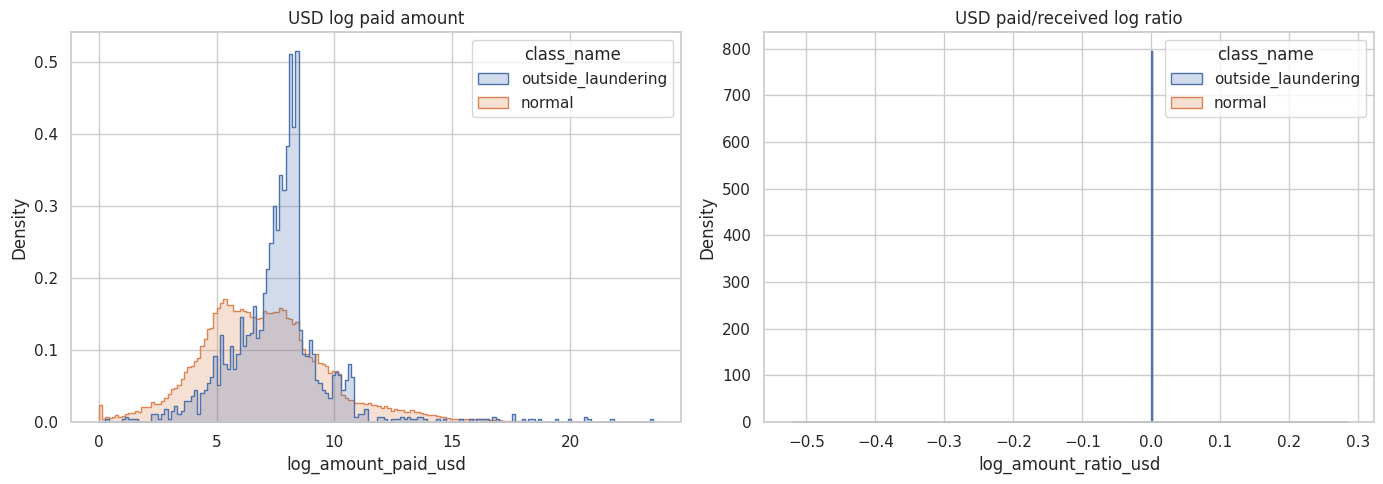

In [14]:
positive_plot = model_df.loc[model_df['target'].eq(1)]
negative_pool = model_df.loc[model_df['target'].eq(0)]
negative_plot = negative_pool.sample(
    n=min(100_000, len(negative_pool)),
    random_state=RANDOM_STATE,
)
plot_sample = pd.concat([positive_plot, negative_plot], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(
    data=plot_sample,
    x='log_amount_paid_usd',
    hue='class_name',
    stat='density',
    common_norm=False,
    element='step',
    ax=axes[0],
)
axes[0].set_title('USD log paid amount')

sns.histplot(
    data=plot_sample,
    x='log_amount_ratio_usd',
    hue='class_name',
    stat='density',
    common_norm=False,
    element='step',
    ax=axes[1],
)
axes[1].set_title('USD paid/received log ratio')
plt.tight_layout()
plt.show()


## 9. 학습용 정상거래 표본 구성

학습에서만 정상거래를 줄입니다. 검증과 테스트는 실제 클래스 비율을 유지해야 실제 환경에서 Precision과 PR-AUC를 해석할 수 있습니다.


In [15]:
train_full = model_df.loc[model_df['split'].eq('train')].copy()
valid_df = model_df.loc[model_df['split'].eq('valid')].copy()
test_df = model_df.loc[model_df['split'].eq('test')].copy()
del model_df
gc.collect()

train_positive = train_full.loc[train_full['target'].eq(1)]
train_negative = train_full.loc[train_full['target'].eq(0)]
negative_n = min(
    len(train_negative),
    len(train_positive) * NEGATIVE_SAMPLE_RATIO,
)
sampled_negative = train_negative.sample(
    n=negative_n,
    random_state=RANDOM_STATE,
)

train_df = pd.concat(
    [train_positive, sampled_negative],
    ignore_index=True,
).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

del train_full, train_positive, train_negative, sampled_negative
gc.collect()

print('학습 표본')
display(train_df['target'].value_counts().sort_index().to_frame('count'))
print('검증 원래 비율')
display(valid_df['target'].value_counts().sort_index().to_frame('count'))
print('테스트 원래 비율')
display(test_df['target'].value_counts().sort_index().to_frame('count'))


학습 표본


,count
target,
0,13860
1,1386


검증 원래 비율


,count
target,
0,482232
1,211


테스트 원래 비율


,count
target,
0,861832
1,371


## 10. 모델 피처와 전처리

계좌번호와 Entity ID 자체는 넣지 않습니다. Payment Format, 통화 범주형 피처, 교차통화 여부, 중복 수취액과 정확한 날짜·요일·주말도 넣지 않습니다. 모든 H 실험은 동일한 여섯 개 기준 피처를 사용하며 선택된 이력 그룹만 추가합니다. 숫자형 값에는 결측치 처리와 표준화를 적용합니다.


In [16]:
BASE_FEATURES = [
    'log_amount_paid_usd',
    'log_amount_ratio_usd',
    'is_cross_bank',
    'is_self_transfer',
    'hour_sin',
    'hour_cos',
]

HISTORY_GROUPS = {
    'H0_none': [],
    'H1_pair': [
        'pair_prev_count_log',
    ],
    'H2_account_activity': [
        'sender_prev_count_log',
        'receiver_prev_count_log',
    ],
    'H3_time_amount': [
        'hours_since_sender_prev_log',
        'amount_vs_sender_history_usd',
    ],
    'H4_all_history': [
        'sender_prev_count_log',
        'receiver_prev_count_log',
        'pair_prev_count_log',
        'hours_since_sender_prev_log',
        'amount_vs_sender_history_usd',
    ],
}

EXCLUDED_MODEL_FEATURES = [
    'log_amount_received_usd',
    'Payment Currency',
    'Receiving Currency',
    'is_cross_currency',
]

assert set(EXCLUDED_MODEL_FEATURES).isdisjoint(BASE_FEATURES)
for group_features in HISTORY_GROUPS.values():
    assert set(EXCLUDED_MODEL_FEATURES).isdisjoint(group_features)

def make_preprocessor(feature_columns):
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ])
    return ColumnTransformer([
        ('num', numeric_pipe, feature_columns),
    ])

print('공통 기준 피처:', BASE_FEATURES)
print('제거한 모델 피처:', EXCLUDED_MODEL_FEATURES)
display(pd.Series(HISTORY_GROUPS, name='추가 이력 피처').to_frame())


공통 기준 피처: ['log_amount_paid_usd', 'log_amount_ratio_usd', 'is_cross_bank', 'is_self_transfer', 'hour_sin', 'hour_cos']
제거한 모델 피처: ['log_amount_received_usd', 'Payment Currency', 'Receiving Currency', 'is_cross_currency']


,추가 이력 피처
H0_none,[]
H1_pair,[pair_prev_count_log]
H2_account_activity,"[sender_prev_count_log, receiver_prev_count_log]"
H3_time_amount,"[hours_since_sender_prev_log, amount_vs_sender..."
H4_all_history,"[sender_prev_count_log, receiver_prev_count_lo..."


## 11. 평가 함수

정확도 대신 PR-AUC, Precision, Recall, F1을 봅니다. 분류 임계값은 테스트가 아니라 검증 데이터에서 F1이 가장 높은 값으로 선택합니다. Precision@K는 조사 우선순위 상위 K건 중 실제 양성 비율을 보여줍니다.


In [17]:
def best_f1_threshold(y_true, scores):
    precision, recall, thresholds = precision_recall_curve(y_true, scores)
    if len(thresholds) == 0:
        return 0.5

    f1_values = (
        2 * precision[:-1] * recall[:-1]
        / (precision[:-1] + recall[:-1] + 1e-12)
    )
    return float(thresholds[np.nanargmax(f1_values)])

def precision_recall_at_k(y_true, scores, k):
    k = min(k, len(scores))
    top_index = np.argsort(-scores)[:k]
    top_true = np.asarray(y_true)[top_index]
    precision_at_k = top_true.mean() if k else np.nan
    recall_at_k = top_true.sum() / max(np.asarray(y_true).sum(), 1)
    return precision_at_k, recall_at_k

def evaluate_model(model, valid_data, test_data, feature_columns):
    valid_scores = model.predict_proba(valid_data[feature_columns])[:, 1]
    threshold = best_f1_threshold(valid_data['target'], valid_scores)

    test_scores = model.predict_proba(test_data[feature_columns])[:, 1]
    test_pred = (test_scores >= threshold).astype('int8')
    y_test = test_data['target'].to_numpy()

    metrics = {
        'threshold': threshold,
        'PR-AUC': average_precision_score(y_test, test_scores),
        'precision': precision_score(y_test, test_pred, zero_division=0),
        'recall': recall_score(y_test, test_pred, zero_division=0),
        'F1': f1_score(y_test, test_pred, zero_division=0),
    }

    for k in [100, 500, 1000]:
        p_at_k, r_at_k = precision_recall_at_k(y_test, test_scores, k)
        metrics[f'precision@{k}'] = p_at_k
        metrics[f'recall@{k}'] = r_at_k

    print('Confusion matrix')
    display(pd.DataFrame(
        confusion_matrix(y_test, test_pred),
        index=['actual_0', 'actual_1'],
        columns=['pred_0', 'pred_1'],
    ))

    return metrics, test_scores


## 12. Logistic Regression 이력 그룹 비교

H0~H4마다 같은 Logistic Regression을 새로 학습합니다. 검증 데이터에서 각 실험의 F1 최적 Threshold를 선택하고, 테스트 데이터의 PR-AUC와 상위 K 성능을 비교합니다. 계수는 표준화된 피처의 조건부 방향을 확인하는 용도로 사용합니다.


In [18]:
GROUP_FEATURE_COLUMNS = {
    group_name: BASE_FEATURES + history_features
    for group_name, history_features in HISTORY_GROUPS.items()
}

logistic_results = {}
logistic_coefficient_tables = {}

for group_name, feature_columns in GROUP_FEATURE_COLUMNS.items():
    print(f'\n===== Logistic Regression: {group_name} =====')
    print('사용 피처:', feature_columns)

    model = Pipeline([
        ('preprocess', make_preprocessor(feature_columns)),
        ('model', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
        )),
    ])

    model.fit(train_df[feature_columns], train_df['target'])
    metrics, test_scores = evaluate_model(
        model,
        valid_df,
        test_df,
        feature_columns,
    )
    logistic_results[group_name] = metrics
    display(pd.Series(metrics, name=group_name).to_frame())

    feature_names = (
        model.named_steps['preprocess']
        .get_feature_names_out()
    )
    coefficient_table = pd.DataFrame({
        'feature': feature_names,
        'coefficient': model.named_steps['model'].coef_[0],
    })
    coefficient_table['feature'] = (
        coefficient_table['feature']
        .str.replace(r'^num__', '', regex=True)
    )
    logistic_coefficient_tables[group_name] = (
        coefficient_table.set_index('feature')['coefficient']
    )

    del model, test_scores
    gc.collect()

logistic_result_table = pd.DataFrame(logistic_results).T
display(logistic_result_table)



===== Logistic Regression: H0_none =====
사용 피처: ['log_amount_paid_usd', 'log_amount_ratio_usd', 'is_cross_bank', 'is_self_transfer', 'hour_sin', 'hour_cos']
Confusion matrix


,pred_0,pred_1
actual_0,495446,366386
actual_1,116,255


,H0_none
threshold,0.498935
PR-AUC,0.000544
precision,0.000696
recall,0.687332
F1,0.001390
precision@100,0.000000
recall@100,0.000000
precision@500,0.002000
recall@500,0.002695
precision@1000,0.001000



===== Logistic Regression: H1_pair =====
사용 피처: ['log_amount_paid_usd', 'log_amount_ratio_usd', 'is_cross_bank', 'is_self_transfer', 'hour_sin', 'hour_cos', 'pair_prev_count_log']
Confusion matrix


,pred_0,pred_1
actual_0,842637,19195
actual_1,177,194


...

,H3_time_amount
threshold,0.891279
PR-AUC,0.000741
precision,0.002299
recall,0.002695
F1,0.002481
precision@100,0.000000
recall@100,0.000000
precision@500,0.004000
recall@500,0.005391
precision@1000,0.002000



===== Logistic Regression: H4_all_history =====
사용 피처: ['log_amount_paid_usd', 'log_amount_ratio_usd', 'is_cross_bank', 'is_self_transfer', 'hour_sin', 'hour_cos', 'sender_prev_count_log', 'receiver_prev_count_log', 'pair_prev_count_log', 'hours_since_sender_prev_log', 'amount_vs_sender_history_usd']
Confusion matrix


,pred_0,pred_1
actual_0,852038,9794
actual_1,350,21


,H4_all_history
threshold,0.951903
PR-AUC,0.002478
precision,0.002140
recall,0.056604
F1,0.004123
precision@100,0.000000
recall@100,0.000000
precision@500,0.002000
recall@500,0.002695
precision@1000,0.001000


,threshold,PR-AUC,precision,recall,F1,precision@100,recall@100,precision@500,recall@500,precision@1000,recall@1000
H0_none,0.498935,0.000544,0.000696,0.687332,0.001390,0.00,0.000000,0.002,0.002695,0.001,0.002695
H1_pair,0.709374,0.005970,0.010006,0.522911,0.019636,0.01,0.002695,0.004,0.005391,0.006,0.016173
H2_account_activity,0.723330,0.001667,0.002617,0.021563,0.004667,0.00,0.000000,0.000,0.000000,0.001,0.002695
H3_time_amount,0.891279,0.000741,0.002299,0.002695,0.002481,0.00,0.000000,0.004,0.005391,0.002,0.005391
H4_all_history,0.951903,0.002478,0.002140,0.056604,0.004123,0.00,0.000000,0.002,0.002695,0.001,0.002695


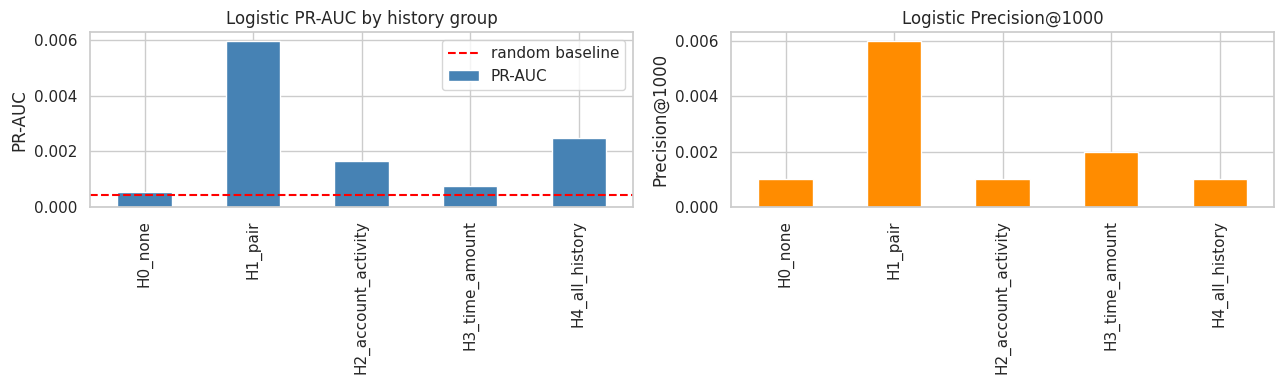

In [19]:
# Logistic 그룹별 PR-AUC와 상위 1,000건 Precision 비교
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

logistic_result_table['PR-AUC'].plot(
    kind='bar',
    ax=axes[0],
    color='steelblue',
)
axes[0].axhline(
    test_df['target'].mean(),
    color='red',
    linestyle='--',
    label='random baseline',
)
axes[0].set_title('Logistic PR-AUC by history group')
axes[0].set_ylabel('PR-AUC')
axes[0].legend()

logistic_result_table['precision@1000'].plot(
    kind='bar',
    ax=axes[1],
    color='darkorange',
)
axes[1].set_title('Logistic Precision@1000')
axes[1].set_ylabel('Precision@1000')

plt.tight_layout()
plt.show()


In [20]:
# 그룹마다 Logistic 계수가 어떻게 달라지는지 한 표로 비교합니다.
logistic_coefficient_comparison = pd.concat(
    logistic_coefficient_tables,
    axis=1,
).reindex(
    BASE_FEATURES + HISTORY_GROUPS['H4_all_history']
)

display(logistic_coefficient_comparison)

print('이력 피처 계수만 확인')
display(
    logistic_coefficient_comparison.loc[
        HISTORY_GROUPS['H4_all_history']
    ]
)


,H0_none,H1_pair,H2_account_activity,H3_time_amount,H4_all_history
feature,,,,,
log_amount_paid_usd,0.291531,0.162192,0.297887,0.647442,0.505184
log_amount_ratio_usd,-0.015233,-0.040679,-0.024504,-0.018257,-0.046126
is_cross_bank,0.100883,0.140925,0.088211,0.088826,0.077810
is_self_transfer,-0.974058,-0.883831,-0.980275,-0.970620,-0.940487
hour_sin,-0.023910,-0.026625,-0.038519,-0.020116,0.016196
hour_cos,-0.042360,-0.086781,-0.041910,-0.034526,-0.110926
sender_prev_count_log,NaN,NaN,0.266669,NaN,1.007348
receiver_prev_count_log,NaN,NaN,-0.515483,NaN,0.652159
pair_prev_count_log,NaN,-0.992896,NaN,NaN,-2.534432


이력 피처 계수만 확인


,H0_none,H1_pair,H2_account_activity,H3_time_amount,H4_all_history
feature,,,,,
sender_prev_count_log,NaN,NaN,0.266669,NaN,1.007348
receiver_prev_count_log,NaN,NaN,-0.515483,NaN,0.652159
pair_prev_count_log,NaN,-0.992896,NaN,NaN,-2.534432
hours_since_sender_prev_log,NaN,NaN,NaN,0.162399,0.072894
amount_vs_sender_history_usd,NaN,NaN,NaN,-0.583249,-0.448749


## 13. Random Forest 이력 그룹 비교

같은 H0~H4 구성으로 Random Forest를 학습해 비선형 관계와 피처 조합에서 이력 그룹의 기여도가 유지되는지 확인합니다. 모든 그룹에서 나무 수와 하이퍼파라미터를 동일하게 사용합니다.


In [21]:
random_forest_results = {}
random_forest_importance_tables = {}

for group_name, feature_columns in GROUP_FEATURE_COLUMNS.items():
    print(f'\n===== Random Forest: {group_name} =====')
    print('사용 피처:', feature_columns)

    model = Pipeline([
        ('preprocess', make_preprocessor(feature_columns)),
        ('model', RandomForestClassifier(
            n_estimators=250,
            min_samples_leaf=5,
            max_features=3,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])

    model.fit(train_df[feature_columns], train_df['target'])
    metrics, test_scores = evaluate_model(
        model,
        valid_df,
        test_df,
        feature_columns,
    )
    random_forest_results[group_name] = metrics
    display(pd.Series(metrics, name=group_name).to_frame())

    feature_names = (
        model.named_steps['preprocess']
        .get_feature_names_out()
    )
    importance_table = pd.DataFrame({
        'feature': feature_names,
        'importance': model.named_steps['model'].feature_importances_,
    })
    importance_table['feature'] = (
        importance_table['feature']
        .str.replace(r'^num__', '', regex=True)
    )
    random_forest_importance_tables[group_name] = (
        importance_table.set_index('feature')['importance']
    )

    del model, test_scores
    gc.collect()

random_forest_result_table = pd.DataFrame(random_forest_results).T
display(random_forest_result_table)



===== Random Forest: H0_none =====
사용 피처: ['log_amount_paid_usd', 'log_amount_ratio_usd', 'is_cross_bank', 'is_self_transfer', 'hour_sin', 'hour_cos']
Confusion matrix


,pred_0,pred_1
actual_0,861464,368
actual_1,371,0


,H0_none
threshold,0.826632
PR-AUC,0.000896
precision,0.000000
recall,0.000000
F1,0.000000
precision@100,0.000000
recall@100,0.000000
precision@500,0.000000
recall@500,0.000000
precision@1000,0.000000



===== Random Forest: H1_pair =====
사용 피처: ['log_amount_paid_usd', 'log_amount_ratio_usd', 'is_cross_bank', 'is_self_transfer', 'hour_sin', 'hour_cos', 'pair_prev_count_log']
Confusion matrix


,pred_0,pred_1
actual_0,854739,7093
actual_1,300,71


...

,H3_time_amount
threshold,0.866556
PR-AUC,0.005880
precision,0.010080
recall,0.102426
F1,0.018353
precision@100,0.020000
recall@100,0.005391
precision@500,0.012000
recall@500,0.016173
precision@1000,0.012000



===== Random Forest: H4_all_history =====
사용 피처: ['log_amount_paid_usd', 'log_amount_ratio_usd', 'is_cross_bank', 'is_self_transfer', 'hour_sin', 'hour_cos', 'sender_prev_count_log', 'receiver_prev_count_log', 'pair_prev_count_log', 'hours_since_sender_prev_log', 'amount_vs_sender_history_usd']
Confusion matrix


,pred_0,pred_1
actual_0,859815,2017
actual_1,339,32


,H4_all_history
threshold,0.903789
PR-AUC,0.007063
precision,0.015617
recall,0.086253
F1,0.026446
precision@100,0.010000
recall@100,0.002695
precision@500,0.014000
recall@500,0.018868
precision@1000,0.015000


,threshold,PR-AUC,precision,recall,F1,precision@100,recall@100,precision@500,recall@500,precision@1000,recall@1000
H0_none,0.826632,0.000896,0.000000,0.000000,0.000000,0.00,0.000000,0.000,0.000000,0.000,0.000000
H1_pair,0.802727,0.006030,0.009911,0.191375,0.018845,0.00,0.000000,0.008,0.010782,0.009,0.024259
H2_account_activity,0.869848,0.004707,0.009288,0.064690,0.016244,0.02,0.005391,0.008,0.010782,0.010,0.026954
H3_time_amount,0.866556,0.005880,0.010080,0.102426,0.018353,0.02,0.005391,0.012,0.016173,0.012,0.032345
H4_all_history,0.903789,0.007063,0.015617,0.086253,0.026446,0.01,0.002695,0.014,0.018868,0.015,0.040431


,H0_none,H1_pair,H2_account_activity,H3_time_amount,H4_all_history
feature,,,,,
log_amount_paid_usd,0.483161,0.288128,0.215460,0.245245,0.125505
log_amount_ratio_usd,0.000227,0.000235,0.000061,0.000085,0.000094
is_cross_bank,0.007356,0.007083,0.003515,0.003536,0.001588
is_self_transfer,0.011175,0.007094,0.005387,0.005733,0.003366
hour_sin,0.247270,0.164086,0.091839,0.084506,0.042260
hour_cos,0.250811,0.172040,0.096826,0.090026,0.053250
sender_prev_count_log,NaN,NaN,0.474422,NaN,0.247945
receiver_prev_count_log,NaN,NaN,0.112490,NaN,0.060706
pair_prev_count_log,NaN,0.361334,NaN,NaN,0.220355


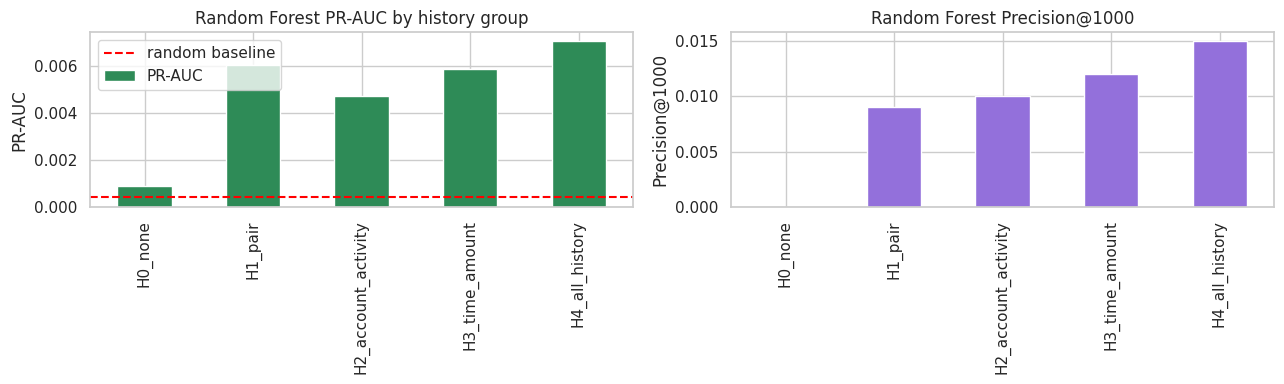

In [22]:
# 그룹별 Random Forest 중요도를 같은 피처 순서로 비교합니다.
random_forest_importance_comparison = pd.concat(
    random_forest_importance_tables,
    axis=1,
).reindex(
    BASE_FEATURES + HISTORY_GROUPS['H4_all_history']
)

display(random_forest_importance_comparison)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

random_forest_result_table['PR-AUC'].plot(
    kind='bar',
    ax=axes[0],
    color='seagreen',
)
axes[0].axhline(
    test_df['target'].mean(),
    color='red',
    linestyle='--',
    label='random baseline',
)
axes[0].set_title('Random Forest PR-AUC by history group')
axes[0].set_ylabel('PR-AUC')
axes[0].legend()

random_forest_result_table['precision@1000'].plot(
    kind='bar',
    ax=axes[1],
    color='mediumpurple',
)
axes[1].set_title('Random Forest Precision@1000')
axes[1].set_ylabel('Precision@1000')

plt.tight_layout()
plt.show()


## 14. Logistic과 Random Forest 통합 비교

H0를 이력 없는 기준점으로 두고 각 그룹의 PR-AUC 증가량과 증가 배수를 계산합니다. 절대 PR-AUC와 Precision@K를 함께 확인해 높은 Recall이 과도한 경고에서 나온 결과인지 구분합니다.


In [23]:
combined_metrics = pd.concat(
    {
        'Logistic Regression': logistic_result_table,
        'Random Forest': random_forest_result_table,
    },
    names=['model', 'history_group'],
)

display(combined_metrics)

contribution_rows = []
for model_name, result_table in [
    ('Logistic Regression', logistic_result_table),
    ('Random Forest', random_forest_result_table),
]:
    h0_pr_auc = result_table.loc['H0_none', 'PR-AUC']

    for group_name, row in result_table.iterrows():
        contribution_rows.append({
            'model': model_name,
            'history_group': group_name,
            'PR-AUC': row['PR-AUC'],
            'PR-AUC_gain_vs_H0': row['PR-AUC'] - h0_pr_auc,
            'PR-AUC_ratio_vs_H0': row['PR-AUC'] / max(h0_pr_auc, 1e-12),
            'precision@100': row['precision@100'],
            'precision@500': row['precision@500'],
            'precision@1000': row['precision@1000'],
            'recall@1000': row['recall@1000'],
        })

history_contribution_table = (
    pd.DataFrame(contribution_rows)
    .set_index(['model', 'history_group'])
)

display(history_contribution_table)


threshold    PR-AUC  precision  \
model               history_group                                         
Logistic Regression H0_none               0.498935  0.000544   0.000696   
                    H1_pair               0.709374  0.005970   0.010006   
                    H2_account_activity   0.723330  0.001667   0.002617   
                    H3_time_amount        0.891279  0.000741   0.002299   
                    H4_all_history        0.951903  0.002478   0.002140   
Random Forest       H0_none               0.826632  0.000896   0.000000   
                    H1_pair               0.802727  0.006030   0.009911   
                    H2_account_activity   0.869848  0.004707   0.009288   
                    H3_time_amount        0.866556  0.005880   0.010080   
                    H4_all_history        0.903789  0.007063   0.015617   

                                           recall        F1  precision@100  \
model               history_group                                            
Logistic Regression H0_none              0.687332  0.001390           0.00   
                    H1_pair              0.522911  0.019636           0.01   
                    H2_account_activity  0.021563  0.004667           0.00   
                    H3_time_amount       0.002695  0.002481           0.00   
                    H4_all_history       0.056604  0.004123           0.00   
Random Forest       H0_none              0.000000  0.000000           0.00   
                    H1_pair              0.191375  0.018845           0.00   
                    H2_account_activity  0.064690  0.016244           0.02   
                    H3_time_amount       0.102426  0.018353           0.02   
                    H4_all_history       0.086253  0.026446           0.01   

                                         recall@100  precision@500  \
model               history_group                                    
Logistic Regression H0_none                0.000000          0.002   
                    H1_pair                0.002695          0.004   
                    H2_account_activity    0.000000          0.000   
                    H3_time_amount         0.000000          0.004   
                    H4_all_history         0.000000          0.002   
Random Forest       H0_none                0.000000          0.000   
                    H1_pair                0.000000          0.008   
                    H2_account_activity    0.005391          0.008   
                    H3_time_amount         0.005391          0.012   
                    H4_all_history         0.002695          0.014   

                                         recall@500  precision@1000  \
model               history_group                                     
Logistic Regression H0_none                0.002695           0.001   
                    H1_pair                0.005391           0.006   
                    H2_account_activity    0.000000           0.001   
                    H3_time_amount         0.005391           0.002   
                    H4_all_history         0.002695           0.001   
Random Forest       H0_none                0.000000           0.000   
                    H1_pair                0.010782           0.009   
                    H2_account_activity    0.010782           0.010   
                    H3_time_amount         0.016173           0.012   
                    H4_all_history         0.018868           0.015   

                                         recall@1000  
model               history_group                     
Logistic Regression H0_none                 0.002695  
                    H1_pair                 0.016173  
                    H2_account_activity     0.002695  
                    H3_time_amount          0.005391  
                    H4_all_history          0.002695  
Random Forest       H0_none                 0.000000  
                    H1_pair                 0.024259  
              

PR-AUC  PR-AUC_gain_vs_H0  \
model               history_group                                      
Logistic Regression H0_none              0.000544           0.000000   
                    H1_pair              0.005970           0.005427   
                    H2_account_activity  0.001667           0.001124   
                    H3_time_amount       0.000741           0.000197   
                    H4_all_history       0.002478           0.001934   
Random Forest       H0_none              0.000896           0.000000   
                    H1_pair              0.006030           0.005133   
                    H2_account_activity  0.004707           0.003811   
                    H3_time_amount       0.005880           0.004983   
                    H4_all_history       0.007063           0.006167   

                                         PR-AUC_ratio_vs_H0  precision@100  \
model               history_group                                            
Logistic Regression H0_none                        1.000000           0.00   
                    H1_pair                       10.983826           0.01   
                    H2_account_activity            3.067151           0.00   
                    H3_time_amount                 1.362773           0.00   
                    H4_all_history                 4.558862           0.00   
Random Forest       H0_none                        1.000000           0.00   
                    H1_pair                        6.728394           0.00   
                    H2_account_activity            5.252623           0.02   
                    H3_time_amount                 6.560934           0.02   
                    H4_all_history                 7.881376           0.01   

                                         precision@500  precision@1000  \
model               history_group                                        
Logistic Regression H0_none                      0.002           0.001   
                    H1_pair                      0.004           0.006   
                    H2_account_activity          0.000           0.001   
                    H3_time_amount               0.004           0.002   
                    H4_all_history               0.002           0.001   
Random Forest       H0_none                      0.000           0.000   
                    H1_pair                      0.008           0.009   
                    H2_account_activity          0.008           0.010   
                    H3_time_amount               0.012           0.012   
                    H4_all_history               0.014           0.015   

                                         recall@1000  
model               history_group                     
Logistic Regression H0_none                 0.002695  
                    H1_pair                 0.016173  
                    H2_account_activity     0.002695  
                    H3_time_amount          0.005391  
                    H4_all_history          0.002695  
Random Forest       H0_none                 0.000000  
                    H1_pair                 0.024259  
                    H2_account_activity     0.026954  
                    H3_time_amount          0.032345  
                    H4_all_history          0.040431

## 15. 결과 해석 순서

1. H0의 PR-AUC를 이력이 없는 기준 성능으로 봅니다.
2. H1이 크게 상승하면 동일 송금자→수취자 거래쌍의 반복 이력이 핵심입니다.
3. H2가 상승하면 송금자·수취자의 개별 활동량이 신호를 제공합니다.
4. H3가 상승하면 직전 거래 간격과 과거 평균 대비 금액이 신호를 제공합니다.
5. H4가 개별 그룹보다 높으면 여러 이력 그룹의 조합 또는 상호작용이 추가로 기여합니다.
6. PR-AUC뿐 아니라 Precision@100·500·1000과 Recall@K를 함께 봅니다.
7. Logistic과 Random Forest에서 같은 그룹이 좋아지는지 확인합니다.
8. 이 단계가 끝난 뒤 pair_prev_count_log와 is_new_pair를 별도로 비교합니다.
9. 마지막으로 가장 좋은 구성에서 hour_sin과 hour_cos를 제거합니다.


===== 모델별 최고 PR-AUC 그룹 =====
Logistic Regression -> H1_pair (PR-AUC=0.005970)
Random Forest -> H4_all_history (PR-AUC=0.007063)


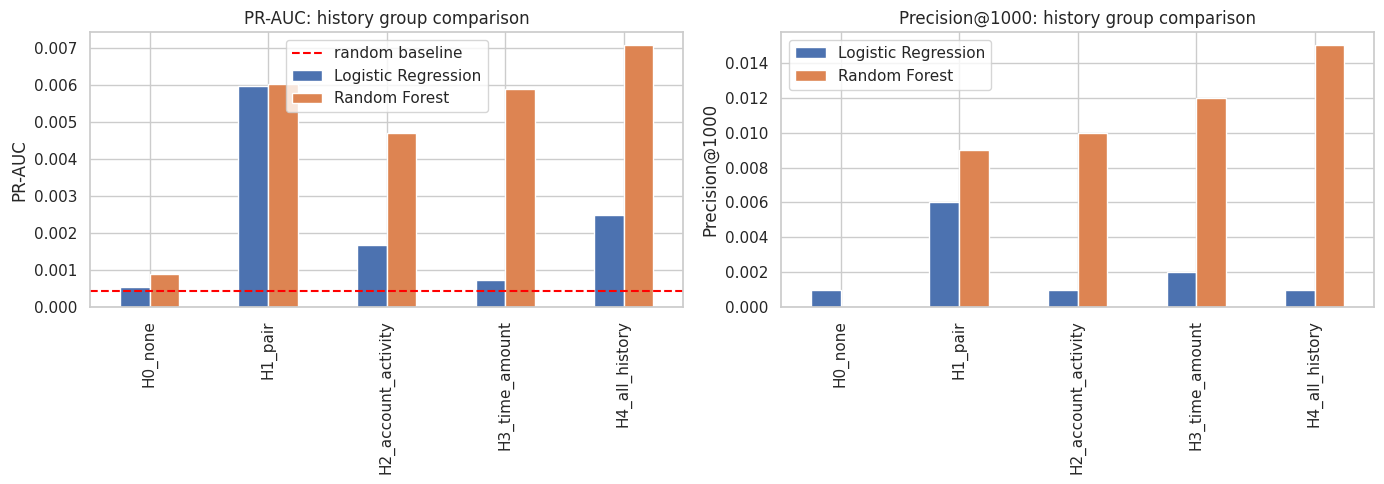

In [24]:
print('===== 모델별 최고 PR-AUC 그룹 =====')
for model_name, result_table in [
    ('Logistic Regression', logistic_result_table),
    ('Random Forest', random_forest_result_table),
]:
    best_group = result_table['PR-AUC'].idxmax()
    print(
        model_name,
        '->',
        best_group,
        f"(PR-AUC={result_table.loc[best_group, 'PR-AUC']:.6f})",
    )

pr_auc_plot = pd.DataFrame({
    'Logistic Regression': logistic_result_table['PR-AUC'],
    'Random Forest': random_forest_result_table['PR-AUC'],
})

precision_1000_plot = pd.DataFrame({
    'Logistic Regression': logistic_result_table['precision@1000'],
    'Random Forest': random_forest_result_table['precision@1000'],
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pr_auc_plot.plot(kind='bar', ax=axes[0])
axes[0].axhline(
    test_df['target'].mean(),
    color='red',
    linestyle='--',
    label='random baseline',
)
axes[0].set_title('PR-AUC: history group comparison')
axes[0].set_ylabel('PR-AUC')
axes[0].legend()

precision_1000_plot.plot(kind='bar', ax=axes[1])
axes[1].set_title('Precision@1000: history group comparison')
axes[1].set_ylabel('Precision@1000')

plt.tight_layout()
plt.show()
